# Epidemic Wave on a Ring — KoopmanGraph Showcase

This notebook is a **visual showcase** of KoopmanGraph on a simple **SIR** epidemic
spreading around a **ring contact network**. Each node carries susceptible, infected,
and recovered fractions $(S, I, R)$ that sum to one. Infection propagates along ring
edges, producing a traveling wave you can read directly from the circular layout.

We simulate ground-truth dynamics, train a topology-aware Koopman model with a
**structurally stable (Schur) operator**, and compare **truth vs forecast** snapshots
on the ring together with the learned spectrum (eigenvalues forced inside the unit disk).
For SIR **contact-reduction / bilinear control** on the same plant, see
`19_bilinear_control_koopman.ipynb`.


## SIR dynamics on a ring graph

Ground-truth snapshots come from
`EpidemicNetworkBenchmark.generate(..., topology="ring")` in
`koopman_graph.datasets`. At each discrete time step, node $i$ feels the average
infected fraction of its neighbors — a discrete networked SIR / force-of-infection
update in the mean-field epidemic-on-networks lineage (cf. Pastor-Satorras &
Vespignani, *Phys. Rev. Lett.* **86**, 3200, 2001, for heterogeneous-network MF;
for Euler networked SIR see e.g. Mei et al., arXiv:2102.12549) — and advances with
a forward-Euler step:

$$
\begin{aligned}
\text{force}_i &= \sum_{j \in \mathcal{N}(i)} I_j / |\mathcal{N}(i)|, \\
I_i^{+} &= I_i + \beta S_i \,\text{force}_i - \gamma I_i, \\
R_i^{+} &= R_i + \gamma I_i, \\
S_i^{+} &= 1 - I_i^{+} - R_i^{+},
\end{aligned}
$$

with non-negativity clamps on $I^{+}$ and $R^{+}$ in code. The $S^{+}$ update is a
**simplex closure**; without clamping it equals the mass-action step
$S^{+} = S - \beta S\,\text{force}$. The ring topology makes spatial structure
easy to see: an outbreak near node 0 creates a wave that travels around the
circle.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.gridspec import GridSpec
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
)
from koopman_graph.training import LossWeights
from koopman_graph.analysis import plot_spectrum
from koopman_graph.datasets import EpidemicNetworkBenchmark
from koopman_graph.training import linear_ramp_loss_weights

# Fixed seed for Restart & Run All reproducibility (model init + training).
SEED = 3
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "font.size": 10,
    }
)


def project_to_simplex(x: torch.Tensor) -> torch.Tensor:
    """Clamp and renormalize S/I/R fractions to the probability simplex."""
    x = x.clamp(min=0.0)
    return x / x.sum(dim=-1, keepdim=True).clamp(min=1e-6)


def ring_edge_index(num_nodes: int) -> torch.Tensor:
    """Ring edges for the dynamic-topology rewiring demo below."""
    src: list[int] = []
    dst: list[int] = []
    for node in range(num_nodes):
        nxt = (node + 1) % num_nodes
        src.extend([node, nxt])
        dst.extend([nxt, node])
    return torch.tensor([src, dst], dtype=torch.long)


def ring_positions(num_nodes: int, *, radius: float = 1.0) -> np.ndarray:
    theta = 2.0 * np.pi * np.arange(num_nodes) / num_nodes
    return np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])


def draw_ring_edges(ax, positions: np.ndarray, *, color: str = "#d8d8d8", lw: float = 0.9) -> None:
    for idx in range(len(positions)):
        nxt = (idx + 1) % len(positions)
        ax.plot(
            [positions[idx, 0], positions[nxt, 0]],
            [positions[idx, 1], positions[nxt, 1]],
            color=color,
            lw=lw,
            zorder=0,
        )


def plot_ring_field(
    ax,
    values: np.ndarray,
    positions: np.ndarray,
    *,
    title: str,
    cmap: str = "magma",
    vmin: float | None = None,
    vmax: float | None = None,
    node_size: float = 130,
):
    draw_ring_edges(ax, positions)
    scatter = ax.scatter(
        positions[:, 0],
        positions[:, 1],
        c=values,
        cmap=cmap,
        s=node_size,
        vmin=vmin,
        vmax=vmax,
        edgecolors="white",
        linewidths=0.45,
        zorder=2,
    )
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, pad=6)
    return scatter


In [2]:
def row_normalized_adjacency(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """Dense row-stochastic adjacency for the rewiring demo only."""
    row, col = edge_index
    adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float32)
    adj[row, col] = 1.0
    deg = adj.sum(dim=1).clamp(min=1.0)
    return adj / deg.unsqueeze(1)


NUM_NODES = 16 if os.environ.get("PYTEST_CURRENT_TEST") else 24
RING_POS = ring_positions(NUM_NODES, radius=1.05)
data_sequence = EpidemicNetworkBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=25 if os.environ.get("PYTEST_CURRENT_TEST") else 45,
    topology="ring",
    beta=0.45,
    gamma=0.12,
    seed=SEED,
)

print(f"Nodes: {data_sequence.num_nodes}")
print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Channels: S, I, R (in_channels={data_sequence.in_channels})")
print("Ground truth from EpidemicNetworkBenchmark.generate (ring topology).")


Nodes: 24
Snapshots: 45
Channels: S, I, R (in_channels=3)
Ground truth from EpidemicNetworkBenchmark.generate (ring topology).


## Ground-truth wave on the ring

Node color encodes the **infected fraction** $I$. The wave originates near node 0
and spreads in **both directions** around the ring; the extra seed at node 1 gives
it a slight head start toward increasing node indices (counterclockwise in this
layout).

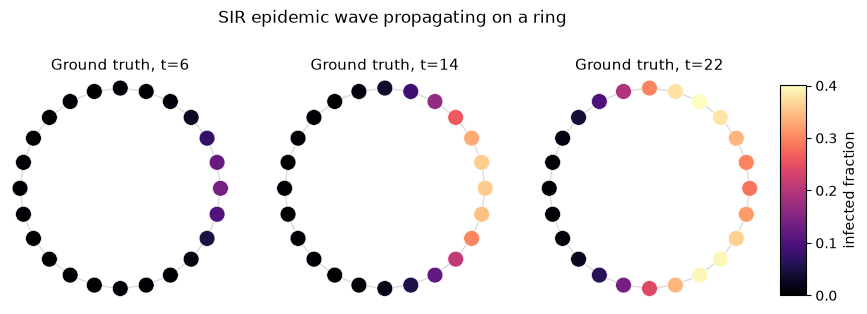

In [3]:
truth_times = [6, 14, 22]
infected_idx = 1
truth_values = [data_sequence[t].x[:, infected_idx].numpy() for t in truth_times]
vmin = 0.0
vmax = max(v.max() for v in truth_values)

fig, axes = plt.subplots(1, len(truth_times), figsize=(3.4 * len(truth_times), 3.4))
scatter_ref = None
for ax, t, values in zip(axes, truth_times, truth_values, strict=True):
    scatter_ref = plot_ring_field(
        ax,
        values,
        RING_POS,
        title=f"Ground truth, t={t}",
        vmin=vmin,
        vmax=vmax,
    )

fig.suptitle("SIR epidemic wave propagating on a ring", y=1.02, fontsize=12)
fig.subplots_adjust(right=0.86)
if scatter_ref is not None:
    cax = fig.add_axes([0.88, 0.18, 0.025, 0.62])
    fig.colorbar(scatter_ref, cax=cax, label="infected fraction")
plt.show()

## Training configuration

The model below uses hyperparameters tuned for **accurate multi-step rollout** on this
ring epidemic (160 epochs interactively) while keeping a **structurally stable** Koopman
operator. Key choices:

- **Fixed `SEED=3`** — `random` / NumPy / PyTorch are seeded so Restart & Run All reproduces
  the printed metrics and spectrum figure; this seed was selected for tight truth–forecast
  spatial match (wave speed and origin-node decay).
- **`koopman_parameterization="schur"`** with `koopman_max_spectral_radius=0.99` — the Schur
  **triangular diagonal** is bounded strictly below that radius so eigenvalues of **K** stay
  inside the unit disk (see `11_long_horizon_stability.ipynb`). Assembled `K` can be
  **non-normal**, so numerical eigendecomposition of `K` can report
  \(\max|\lambda|\) slightly above the configured diagonal bound while remaining
  \(|\lambda| < 1\). The stability claim is \(n_{\mathrm{outside}}=0\), not equality to \(0.99\).
- **3-layer GCN** encoder/decoder (`48` channels) — deeper than the default 2-layer stack.
- **Loss ramp** — start with reconstruction only, then ramp forward (`0.8`), backward, and
  rollout (`2.0`) weights so multi-step supervision dominates late training.
- **Rollout horizon** (`14` steps) covering the 8-step evaluation window with margin, so the
  model learns wave advance past the scored horizon.
- Learning rate `5e-4` and **gradient clipping** for stable late-step forecasts under Schur.


In [4]:
IN_CHANNELS = 3
HIDDEN = 48
LATENT = 48
NUM_LAYERS = 3
EPOCHS = 30 if os.environ.get("PYTEST_CURRENT_TEST") else 160
FORECAST_START = 14
PREDICT_STEPS = 8
ROLLOUT_HORIZON = 14
LR = 5e-4
RAMP_EPOCHS = 15 if os.environ.get("PYTEST_CURRENT_TEST") else 40
KOOPMAN_MAX_RADIUS = 0.99

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
encoder = GNNEncoder(IN_CHANNELS, HIDDEN, LATENT, num_layers=NUM_LAYERS)
decoder = GNNDecoder(LATENT, HIDDEN, IN_CHANNELS, num_layers=NUM_LAYERS)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT,
    time_step=1.0,
    koopman_parameterization="schur",
    koopman_max_spectral_radius=KOOPMAN_MAX_RADIUS,
)

recon_only = LossWeights(reconstruction=1.0, forward=0.0, backward=0.0, rollout=0.0)
rollout_focus = LossWeights(reconstruction=1.0, forward=0.8, backward=0.1, rollout=2.0)
loss_schedule = linear_ramp_loss_weights(recon_only, rollout_focus, ramp_epochs=RAMP_EPOCHS)

history = model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=LR,
    loss_weight_schedule=loss_schedule,
    rollout_horizon=ROLLOUT_HORIZON,
    max_grad_norm=1.0,
)
print(f"SEED: {SEED}")
print(f"Epochs: {EPOCHS}")
print(f"Final loss: {history.loss[-1]:.6f}")
print(f"Koopman parameterization: {model.koopman.parameterization}")

SEED: 3
Epochs: 160
Final loss: 0.008112
Koopman parameterization: schur


## Truth vs Koopman forecast

We roll out from timestep **`FORECAST_START`** when the infection front is already
visible on the ring. Decoder outputs are projected back to the S/I/R simplex before
scoring and plotting.

**Protocol note:** training uses the **full** snapshot sequence, so the reported rollout MSE
is an **in-sample** open-loop check (teaching showcase), not a held-out forecast origin.

The panels below are the primary teaching point: matched truth/forecast infected fields
on the ring, with rollout MSE reported above the figure. A separate spectrum plot follows;
because we trained with Schur parameterization, every eigenvalue satisfies
$|\lambda| < 1$. Modes **nearest** the unit circle are the slowest-decaying directions
of the learned operator (plausible carriers of the persistent wave; we do not plot mode
shapes here).

In [5]:
initial_graph = data_sequence[FORECAST_START]
future_graphs = model.predict(initial_graph, steps=PREDICT_STEPS)
ground_truth = data_sequence[FORECAST_START + 1 : FORECAST_START + 1 + PREDICT_STEPS]

projected_graphs = [
    Data(x=project_to_simplex(pred.x), edge_index=pred.edge_index)
    for pred in future_graphs
]

mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(projected_graphs, ground_truth, strict=True)
        ]
    )
)
print(f"Rollout MSE from t={FORECAST_START} ({PREDICT_STEPS} steps): {mse.item():.6f}")
print(
    f"Mean infected fraction at forecast origin (t={FORECAST_START}): "
    f"{initial_graph.x[:, infected_idx].mean().item():.4f}"
)

Rollout MSE from t=14 (8 steps): 0.000881
Mean infected fraction at forecast origin (t=14): 0.1106


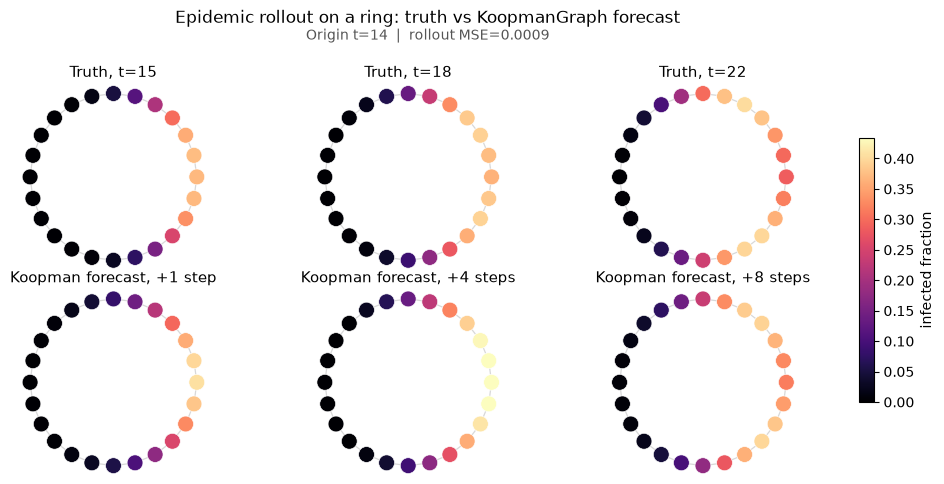

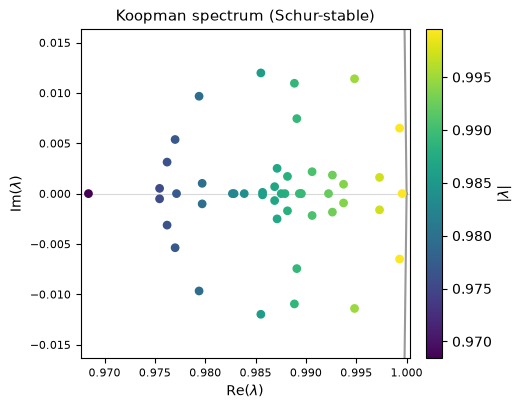

Koopman parameterization: schur
Configured max spectral radius: 0.99
max |λ| (eigendecomposition): 0.9996
Modes with |λ| > 1: 0


In [6]:
panel_steps = [1, 4, 8]
panel_steps = [s for s in panel_steps if s <= PREDICT_STEPS]

all_i = []
for step in panel_steps:
    idx = step - 1
    all_i.append(ground_truth[idx].x[:, infected_idx].numpy())
    all_i.append(projected_graphs[idx].x[:, infected_idx].numpy())
vmin = 0.0
vmax = max(values.max() for values in all_i)

fig = plt.figure(figsize=(9.8, 4.8))
gs = GridSpec(2, len(panel_steps), wspace=0.08, hspace=0.12)

scatter_ref = None
for col, step in enumerate(panel_steps):
    idx = step - 1
    truth_vals = ground_truth[idx].x[:, infected_idx].numpy()
    pred_vals = projected_graphs[idx].x[:, infected_idx].numpy()

    ax_truth = fig.add_subplot(gs[0, col])
    scatter_ref = plot_ring_field(
        ax_truth,
        truth_vals,
        RING_POS,
        title=f"Truth, t={FORECAST_START + step}",
        vmin=vmin,
        vmax=vmax,
    )

    ax_pred = fig.add_subplot(gs[1, col])
    plot_ring_field(
        ax_pred,
        pred_vals,
        RING_POS,
        title=f"Koopman forecast, +{step} step{'s' if step != 1 else ''}",
        vmin=vmin,
        vmax=vmax,
    )

fig.text(0.5, 0.99, "Epidemic rollout on a ring: truth vs KoopmanGraph forecast", ha="center", fontsize=12)
fig.text(0.5, 0.955, f"Origin t={FORECAST_START}  |  rollout MSE={mse.item():.4f}", ha="center", fontsize=10, color="#555555")

fig.subplots_adjust(top=0.86, bottom=0.05, left=0.04, right=0.92)
if scatter_ref is not None:
    cax = fig.add_axes([0.94, 0.20, 0.015, 0.55])
    cbar = fig.colorbar(scatter_ref, cax=cax)
    cbar.set_label("infected fraction")

plt.show()

fig_spec, ax_spec = plt.subplots(figsize=(5.2, 4.2))
spectrum = model.spectrum()
# Zoom to eigenvalue cloud (Schur modes cluster near |λ|≈1).
scatter_spec = plot_spectrum(
    spectrum,
    ax=ax_spec,
    limits="data",
    point_size=28,
)
ax_spec.set_title("Koopman spectrum (Schur-stable)", pad=6)
ax_spec.tick_params(labelsize=8)
cbar_spec = fig_spec.colorbar(scatter_spec, ax=ax_spec, fraction=0.046, pad=0.04)
cbar_spec.set_label(r"$|\lambda|$")
fig_spec.tight_layout()
plt.show()

magnitudes = spectrum.magnitudes.detach()
max_mag = float(magnitudes.max())
n_outside = int((magnitudes > 1.0 + 1e-5).sum())
print(f"Koopman parameterization: {model.koopman.parameterization}")
print(f"Configured max spectral radius: {KOOPMAN_MAX_RADIUS}")
print(f"max |λ| (eigendecomposition): {max_mag:.4f}")
print(f"Modes with |λ| > 1: {n_outside}")
# Schur constrains the triangular diagonal; assembled K can be non-normal, so
# eigendecomposition of K can report max |λ| slightly above KOOPMAN_MAX_RADIUS
# while remaining < 1. Stability claim is n_outside == 0, not equality to 0.99.
assert n_outside == 0, "Schur parameterization should keep all eigenvalues inside the unit disk"


## Rewiring contact network (dynamic topology)

Real contact networks **rewire** over time: people change routines, interventions add or
remove edges, and mobility patterns shift. KoopmanGraph supports this via
`allow_dynamic_topology=True` on `GraphSnapshotSequence`.

Below we alternate between the full ring and a sparser contact graph every few
timesteps. Training uses each snapshot's own `edge_index`; prediction passes the
known future rewiring schedule through `future_topologies` (shorter schedules
**hold the last known** topology for remaining steps). This cell is a short API check
with few epochs, so the printed rewiring rollout MSE is expected to be much larger
than the main ring showcase above; for a fuller networked-operator rewiring study see
`18_networked_koopman_dynamic_topology.ipynb`.

In [7]:
def sparse_contact_edge_index(num_nodes: int) -> torch.Tensor:
    """Return bidirectional edges between even-indexed ring neighbors only."""
    src: list[int] = []
    dst: list[int] = []
    for node in range(0, num_nodes, 2):
        nxt = (node + 2) % num_nodes
        src.extend([node, nxt])
        dst.extend([nxt, node])
    return torch.tensor([src, dst], dtype=torch.long)


def simulate_sir_rewiring(
    *,
    num_nodes: int = NUM_NODES,
    num_timesteps: int = 20,
    rewire_period: int = 5,
    beta: float = 0.45,
    gamma: float = 0.12,
) -> GraphSnapshotSequence:
    """Simulate SIR dynamics on a periodically rewired ring contact graph."""
    snapshots: list[Data] = []
    s = torch.ones(num_nodes, dtype=torch.float32)
    i = torch.zeros(num_nodes, dtype=torch.float32)
    r = torch.zeros(num_nodes, dtype=torch.float32)
    i[0] = 0.08
    i[1] = 0.03
    s = (1.0 - i - r).clamp(min=0.0)

    for t in range(num_timesteps):
        use_ring = (t // rewire_period) % 2 == 0
        edges = ring_edge_index(num_nodes) if use_ring else sparse_contact_edge_index(num_nodes)
        snapshots.append(Data(x=torch.stack([s, i, r], dim=1), edge_index=edges))
        if t == num_timesteps - 1:
            break
        adj = row_normalized_adjacency(edges, num_nodes)
        neighbor_i = adj @ i
        infection = beta * s * neighbor_i
        recovered = gamma * i
        i = (i + infection - recovered).clamp(min=0.0)
        r = (r + recovered).clamp(min=0.0)
        s = (1.0 - i - r).clamp(min=0.0)

    return GraphSnapshotSequence(snapshots, allow_dynamic_topology=True)


rewire_sequence = simulate_sir_rewiring(
    num_nodes=NUM_NODES,
    num_timesteps=12 if os.environ.get("PYTEST_CURRENT_TEST") else 30,
    rewire_period=4,
)
print(f"Dynamic topology: {rewire_sequence.is_dynamic_topology}")
print(f"Snapshots: {rewire_sequence.num_timesteps}")

torch.manual_seed(SEED + 1)
np.random.seed(SEED + 1)
random.seed(SEED + 1)
rewire_encoder = GNNEncoder(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN,
    latent_dim=LATENT,
    num_layers=NUM_LAYERS,
)
rewire_decoder = GNNDecoder(
    latent_dim=LATENT,
    hidden_channels=HIDDEN,
    out_channels=IN_CHANNELS,
    num_layers=NUM_LAYERS,
)
rewire_model = GraphKoopmanModel(
    encoder=rewire_encoder,
    decoder=rewire_decoder,
    latent_dim=LATENT,
    time_step=1.0,
    koopman_parameterization="schur",
    koopman_max_spectral_radius=KOOPMAN_MAX_RADIUS,
)
rewire_epochs = 6 if os.environ.get("PYTEST_CURRENT_TEST") else 20
rewire_history = rewire_model.fit(
    rewire_sequence,
    epochs=rewire_epochs,
    lr=LR,
    loss_weights=LossWeights(reconstruction=1.0, forward=0.5),
)
print(f"Rewiring train loss: start={rewire_history.loss[0]:.4f} end={rewire_history.loss[-1]:.4f}")

rewire_start = 4
rewire_steps = 3
future_topologies = rewire_sequence.snapshots[rewire_start + 1 : rewire_start + 1 + rewire_steps]
rewire_preds = rewire_model.predict(
    rewire_sequence[rewire_start],
    steps=rewire_steps,
    future_topologies=future_topologies,
)
assert len(rewire_preds) == rewire_steps
assert rewire_preds[0].edge_index.shape == future_topologies[0].edge_index.shape
rewire_truth = rewire_sequence.snapshots[
    rewire_start + 1 : rewire_start + 1 + rewire_steps
]
rewire_mse = torch.mean(
    torch.stack(
        [
            torch.mean((project_to_simplex(pred.x) - truth.x) ** 2)
            for pred, truth in zip(rewire_preds, rewire_truth, strict=True)
        ]
    )
)
print(f"Rewiring rollout MSE ({rewire_steps} steps): {rewire_mse.item():.6f}")
print(
    f"(Secondary fit: {rewire_epochs} epochs — MSE is not comparable to the "
    "main showcase rollout.)"
)
print("Dynamic-topology rollout complete.")


Dynamic topology: True
Snapshots: 30
Rewiring train loss: start=0.2558 end=0.0804
Rewiring rollout MSE (3 steps): 0.030462
(Secondary fit: 20 epochs — MSE is not comparable to the main showcase rollout.)
Dynamic-topology rollout complete.


## Takeaways

- Packaged `EpidemicNetworkBenchmark` supplies the ring SIR ground truth used above.
- A ring graph turns epidemic spread into an intuitive **traveling wave** of infection.
- A **Schur-stable** Koopman operator keeps eigenvalues of **K** inside the unit disk,
  which supports stable long-horizon rollouts.
- Dynamic topology (rewiring) is demonstrated inline above as a short API check; see
  `18_networked_koopman_dynamic_topology.ipynb` for a deeper treatment, and
  `19_bilinear_control_koopman.ipynb` for SIR contact-reduction control.
